In [2]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score
import time

def train_eval_model(name, model, x_tr, y_tr, x_va, y_va):
    '''trains and evaluates the model'''
    t1 = time.time()
    model.fit(x_tr, y_tr)
    t2 = time.time()

    #get predictions
    pred = model.predict(x_va)

    acc = accuracy_score(y_va, pred)
    prec = precision_score(y_va, pred, average="weighted", zero_division=1)
    recall = recall_score(y_va, pred, average="weighted", zero_division=1)

    print(f"Model: {name}")
    print(f"Training Time: {t2-t1:.3f}")
    print(f'acc: {acc:.4f}')
    print(f'prec:{prec:.4f}')
    print(f'recall:{recall:.4f}\n')


data = np.load('octmnist.npz')
print("Keys in octmnist.npz: ", data.files)

for k in data.files:
    arr = data[k]
    print(f"{k:>12}: shape = {arr.shape}")

train_images = data["train_images"]
train_labels = data["train_labels"].ravel()

val_images = data["val_images"]
val_labels = data["val_labels"].ravel()

test_images = data["test_images"]
test_labels = data["test_labels"].ravel()


Keys in octmnist.npz:  ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
train_images: shape = (97477, 28, 28)
  val_images: shape = (10832, 28, 28)
 test_images: shape = (1000, 28, 28)
train_labels: shape = (97477, 1)
  val_labels: shape = (10832, 1)
 test_labels: shape = (1000, 1)


In [3]:
from utils import stratified_subset

x_tr, y_tr = stratified_subset(train_images, train_labels, 22000)
x_va, y_va = stratified_subset(val_images, val_labels, 2000)

In [5]:
x_tr

array([[[253, 254, 254, ..., 254, 255, 255],
        [255, 255, 255, ..., 253, 254, 255],
        [253, 253, 254, ..., 255, 255, 255],
        ...,
        [ 14,  14,  13, ...,  13,  13,  13],
        [ 13,  12,  12, ...,  12,  12,  12],
        [ 12,  11,  11, ...,  11,  11,  11]],

       [[ 21,  23,  25, ..., 146, 151, 157],
        [ 23,  23,  24, ...,  22,  24,  26],
        [ 27,  26,  26, ...,  29,  29,  29],
        ...,
        [ 11,  10,  10, ...,  12,  12,  12],
        [ 12,  11,  10, ...,  11,  11,  11],
        [ 13,  12,  10, ...,  10,  10,  10]],

       [[ 14,  14,  13, ...,  14,  14,  14],
        [ 18,  18,  18, ...,  18,  20,  21],
        [ 20,  20,  20, ...,  15,  16,  18],
        ...,
        [  9,   9,   9, ...,   9,   9,   9],
        [  8,   8,   8, ...,   8,   8,   8],
        [  6,   6,   6, ...,   7,   7,   7]],

       ...,

       [[121, 117, 111, ...,  23,  25,  26],
        [ 29,  28,  26, ...,  25,  27,  29],
        [ 25,  25,  25, ...,  27,  27,  28

Components for 95% variance: 42
Components for 99% variance: 133


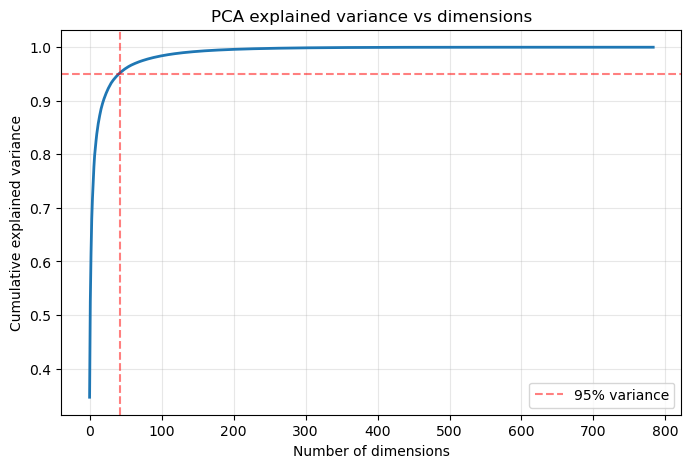

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Flatten 28x28 images to 784-dim vectors
x_tr_flat = x_tr.reshape(-1, 28 * 28)

# Fit PCA without specifying n_components -> keeps all 784
pca = PCA()
pca.fit(x_tr_flat)

# Cumulative explained variance
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Find n_components needed for common variance thresholds
d_95 = np.argmax(cumsum >= 0.95) + 1
d_99 = np.argmax(cumsum >= 0.99) + 1
print(f"Components for 95% variance: {d_95}")
print(f"Components for 99% variance: {d_99}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(cumsum, linewidth=2)
plt.axhline(y=0.95, color="r", linestyle="--", alpha=0.5, label="95% variance")
plt.axvline(x=d_95, color="r", linestyle="--", alpha=0.5)
plt.xlabel("Number of dimensions")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance vs dimensions")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [9]:
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC

# Flatten 28x28 images
x_val_flat = x_va.reshape(-1, 28 * 28)

# Fit PCA keeping 99% of variance (sklearn picks n_components automatically)
pca = PCA(n_components=0.99)
x_train_pca = pca.fit_transform(x_tr_flat)
x_val_pca = pca.transform(x_val_flat)

print(f"Original dimensions: {x_tr_flat.shape[1]}")
print(f"Reduced dimensions:  {pca.n_components_}")
print(f"Explained variance:  {pca.explained_variance_ratio_.sum():.4f}\n")

# Train and evaluate using your existing function
train_eval_model(
    f"LinearSVC + PCA({pca.n_components_})",
    LinearSVC(max_iter=2000, dual="auto"),
    x_tr=x_train_pca, y_tr=y_tr,
    x_va=x_val_pca, y_va=y_va,
)

Original dimensions: 784
Reduced dimensions:  133
Explained variance:  0.9901

Model: LinearSVC + PCA(133)
Training Time: 19.490
acc: 0.6475
prec:0.6919
recall:0.6475



In [10]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)
sample_weights_valid = compute_sample_weight(class_weight="balanced", y=y_va)

In [11]:
import tensorflow as tf
from pathlib import Path
from time import strftime

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
      
def get_run_logdir(root_logdir='my_logs'):
    return Path(root_logdir)/strftime("run_%Y_%m_%d_%H_%M_%S")      

run_logdir = get_run_logdir()

tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))

In [ ]:
import time
import numpy as np
import tensorflow as tf
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scikeras.wrappers import KerasClassifier

from utils import flattener


def create_wide_and_deep_pca(meta, n_pca=50):
    n_features = meta["X_shape_"][1]

    inputs = tf.keras.layers.Input(shape=(n_features,))
    wide_input = tf.keras.layers.Lambda(lambda x: x[:, :n_pca])(inputs)
    deep_input = tf.keras.layers.Lambda(lambda x: x[:, n_pca:])(inputs)

    deep = tf.keras.layers.Dense(300, activation="relu")(deep_input)
    deep = tf.keras.layers.Dense(300, activation="relu")(deep)

    concat = tf.keras.layers.Concatenate()([wide_input, deep])
    output = tf.keras.layers.Dense(4, activation="softmax")(concat)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )
    return model


N_PCA = 50

wide_deep_features = FeatureUnion([
    ("pca",         PCA(n_components=N_PCA, random_state=42)),
    ("passthrough", FunctionTransformer(lambda x: x, validate=False)),
])

clf_wide_pca = KerasClassifier(
    model=create_wide_and_deep_pca,
    model__n_pca=N_PCA,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_cb, tensorboard_cb],
    verbose=1,
)

pipe_wide_pca = Pipeline([
    ("flat",     flattener),
    ("scale",    MinMaxScaler()),
    ("features", wide_deep_features),
    ("model",    clf_wide_pca),
])

# --- Manual fit + eval ---
name = "Wide & Deep with PCA wide input"

t1 = time.time()
pipe_wide_pca.fit(x_tr, y_tr, model__sample_weight=sample_weights)
t2 = time.time()

pred = pipe_wide_pca.predict(x_va).argmax(axis=1)
acc = accuracy_score(y_va, pred)
prec = precision_score(y_va, pred, average="weighted", zero_division=1)
rec = recall_score(y_va, pred, average="weighted", zero_division=1)

print(f"Model: {name}")
print(f"Training Time: {t2 - t1:.3f}")
print(f"acc:    {acc:.4f}")
print(f"prec:   {prec:.4f}")
print(f"recall: {rec:.4f}")

Epoch 1/100
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4210 - loss: 1.3056
Epoch 2/100
 56/688 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4700 - loss: 1.2009

c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4964 - loss: 1.1962
Epoch 3/100
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5252 - loss: 1.1431
Epoch 4/100
249/688 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5517 - loss: 1.0966

KeyboardInterrupt: 

In [14]:
x_tr.shape

(22000, 28, 28)

In [17]:
def prep_for_cnn(X):
    X = X.astype("float32") / 255.0
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
    return X

#we first need to make sure the data is ready for a cnn (see utils helper)
x_tr_cnn = prep_for_cnn(x_tr) #train
x_va_cnn = prep_for_cnn(x_va) #validation

In [24]:
from functools import partial

DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal",
                        use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)
    
model = tf.keras.Sequential([
    DefaultConv2D(32, kernel_size=3, strides=1, input_shape=(28, 28, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
])
prev_filters = 32
for filters in [32] * 2 + [64] * 2 + [128] * 2:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

model.add(tf.keras.layers.GlobalAvgPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(4, activation="softmax"))

c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
name = "ResNet Architecture"

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseCategoricalAccuracy(name="sparse_acc"),
    ],
)

t1 = time.time()
model.fit(x_tr, y_tr, epochs=50, sample_weight=sample_weights, callbacks=[tensorboard_cb, early_stopping_cb])
t2 = time.time()

pred = model.predict(x_va_cnn).argmax(axis=1)
acc = accuracy_score(y_va, pred)
prec = precision_score(y_va, pred, average="weighted", zero_division=1)
rec = recall_score(y_va, pred, average="weighted", zero_division=1)

print(f"Model: {name}")
print(f"Training Time: {t2 - t1:.3f}")
print(f"acc:    {acc:.4f}")
print(f"prec:   {prec:.4f}")
print(f"recall: {rec:.4f}")

Epoch 1/50
 99/688 ━━━━━━━━━━━━━━━━━━━━ 1:29 152ms/step - accuracy: 0.7872 - loss: 0.5425 - sparse_acc: 0.7872WARNING:tensorflow:Trace already enabled
688/688 ━━━━━━━━━━━━━━━━━━━━ 160s 223ms/step - accuracy: 0.7996 - loss: 0.5366 - sparse_acc: 0.7996
Epoch 2/50


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,sparse_acc
  current = self.get_monitor_value(logs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 131s 191ms/step - accuracy: 0.8291 - loss: 0.4705 - sparse_acc: 0.8291
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 140s 203ms/step - accuracy: 0.8432 - loss: 0.4286 - sparse_acc: 0.8432
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 135s 197ms/step - accuracy: 0.8571 - loss: 0.3865 - sparse_acc: 0.8571
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 145s 210ms/step - accuracy: 0.8632 - loss: 0.3660 - sparse_acc: 0.8632
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 142s 206ms/step - accuracy: 0.8738 - loss: 0.3322 - sparse_acc: 0.8738
Epoch 7/50
602/688 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step - accuracy: 0.8877 - loss: 0.3057 - sparse_acc: 0.8877

KeyboardInterrupt: 

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, auc
from sklearn.model_selection import cross_val_score
import time
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)


def evaluate_keras_on_test(
    name,
    model_builder,            # callable returning a fresh compiled tf.keras.Model
    x_tr, y_tr,
    x_te, y_te,
    sample_weights=None,
    fit_kwargs=None,          # dict forwarded to model.fit (epochs, batch_size, callbacks, ...)
    class_names=None,
    n_splits=5,
    random_state=42,
):
    y_tr = np.ravel(y_tr)
    y_te = np.ravel(y_te)
    fit_kwargs = dict(fit_kwargs or {})

    # ------- Manual k-fold cross-validation -------
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_acc, cv_prec, cv_rec = [], [], []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(x_tr, y_tr), start=1):
        x_fold_tr, x_fold_va = x_tr[train_idx], x_tr[val_idx]
        y_fold_tr, y_fold_va = y_tr[train_idx], y_tr[val_idx]
        sw_fold = sample_weights[train_idx] if sample_weights is not None else None

        fold_model = model_builder()  # fresh model each fold
        fold_model.fit(x_fold_tr, y_fold_tr, sample_weight=sw_fold, **fit_kwargs)

        fold_pred = fold_model.predict(x_fold_va, verbose=0).argmax(axis=1)
        cv_acc.append(accuracy_score(y_fold_va, fold_pred))
        cv_prec.append(precision_score(y_fold_va, fold_pred, average="weighted", zero_division=1))
        cv_rec.append(recall_score(y_fold_va, fold_pred, average="weighted", zero_division=1))
        print(f"  fold {fold_idx}: acc={cv_acc[-1]:.4f}  prec={cv_prec[-1]:.4f}  rec={cv_rec[-1]:.4f}")

        tf.keras.backend.clear_session()  # free GPU memory between folds

    cv_acc, cv_prec, cv_rec = map(np.array, (cv_acc, cv_prec, cv_rec))
    print("\nCross-Validation Results:")
    print(f"Accuracy:  {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
    print(f"Precision: {cv_prec.mean():.4f}")
    print(f"Recall:    {cv_rec.mean():.4f}")

    # ------- Final fit on full training set -------
    final_model = model_builder()
    t1 = time.time()
    final_model.fit(x_tr, y_tr, sample_weight=sample_weights, **fit_kwargs)
    t2 = time.time()

    # ------- Test set evaluation -------
    y_score = final_model.predict(x_te, verbose=0)   # (n, n_classes) probabilities
    y_pred = y_score.argmax(axis=1)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=1)
    rec = recall_score(y_te, y_pred, average="weighted", zero_division=1)

    print(f"\nModel: {name}")
    print(f"Training Time: {t2 - t1:.3f}s")
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall:    {rec:.4f}")

    result = {
        "Model": name,
        "CV Accuracy": cv_acc.mean(),
        "CV Precision": cv_prec.mean(),
        "CV Recall": cv_rec.mean(),
        "Train Time (s)": t2 - t1,
        "Test Accuracy": acc,
        "Test Precision": prec,
        "Test Recall": rec,
    }

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC curves
    classes = np.unique(y_te)
    y_te_bin = label_binarize(y_te, classes=classes)

    auc_macro = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="macro")
    auc_weighted = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="weighted")
    result["Test AUC Macro"] = auc_macro
    result["Test AUC Weighted"] = auc_weighted

    print(f"Test AUC Macro:    {auc_macro:.4f}")
    print(f"Test AUC Weighted: {auc_weighted:.4f}")

    plt.figure(figsize=(8, 6))
    for i in range(y_te_bin.shape[1]):
        fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_score[:, i])
        roc_auc_val = auc(fpr, tpr)
        label = class_names[i] if class_names is not None else f"Class {i}"
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_val:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - {name}")
    plt.legend()
    plt.show()

    return result

In [32]:
def evaluate_on_test(name, model, x_tr, y_tr, x_te, y_te, class_names=None):

    y_tr = np.ravel(y_tr)
    y_te = np.ravel(y_te)

    k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_validate(
        model,
        x_tr,
        y_tr,
        cv=k_fold,
        scoring=["accuracy", "precision_weighted", "recall_weighted"],
        n_jobs=-1
    )

    print("Cross-Validation Results:")
    print(f"Accuracy:  {cv_scores['test_accuracy'].mean():.4f} ± {cv_scores['test_accuracy'].std():.4f}")
    print(f"Precision: {cv_scores['test_precision_weighted'].mean():.4f}")
    print(f"Recall:    {cv_scores['test_recall_weighted'].mean():.4f}")

    t1 = time.time()
    model.fit(x_tr, y_tr)
    t2 = time.time()

    y_pred = model.predict(x_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=1)
    rec = recall_score(y_te, y_pred, average="weighted", zero_division=1)

    result = {
        "Model": name,
        "CV Accuracy": cv_scores["test_accuracy"].mean(),
        "CV Precision": cv_scores["test_precision_weighted"].mean(),
        "CV Recall": cv_scores["test_recall_weighted"].mean(),
        "Train Time (s)": t2 - t1,
        "Test Accuracy": acc,
        "Test Precision": prec,
        "Test Recall": rec
    }

    print(f"\nModel: {name}")
    print(f"Training Time: {t2 - t1:.3f}s")
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall:    {rec:.4f}")

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_te)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(x_te)

    if y_score is not None:
        classes = np.unique(y_te)
        y_te_bin = label_binarize(y_te, classes=classes)

        auc_macro = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="macro")
        auc_weighted = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="weighted")

        result["Test AUC Macro"] = auc_macro
        result["Test AUC Weighted"] = auc_weighted

        print(f"Test AUC Macro:    {auc_macro:.4f}")
        print(f"Test AUC Weighted: {auc_weighted:.4f}")

        plt.figure(figsize=(8, 6))
        for i in range(y_te_bin.shape[1]):
            fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_score[:, i])
            roc_auc_val = auc(fpr, tpr)
            label = class_names[i] if class_names is not None else f"Class {i}"
            plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_val:.3f})")

        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves - {name}")
        plt.legend()
        plt.show()
    else:
        result["Test AUC Macro"] = np.nan
        result["Test AUC Weighted"] = np.nan
        print("ROC/AUC not available for this model.")

    return result
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc
from utils import stratified_subset

class_names = [
    "Normal",
    "CNV",
    "DME",
    "Drusen"
]

x_tr_final, y_tr_final = stratified_subset(train_images, train_labels.ravel(), 1000)

results_test = []

results_test.append(
    evaluate_on_test("Wide and Deep",
    pipe_wide_pca,
    x_tr_final, y_tr_final,
    test_images, test_labels,
    class_names=class_names)
)
    

TypeError: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_2', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 2246743347744}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 28, 28, 1], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer_4', 'optional': False}, 'registered_name': None}, {'module': 'keras.layers', 'class_name': 'Conv2D', 'config': {'name': 'conv2d_37', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'filters': 

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
)
from scikeras.wrappers import KerasClassifier

from utils import flattener

x_tr, y_tr = stratified_subset(train_images, train_labels, 30000)
x_va, y_va = stratified_subset(val_images, val_labels, 2000)

def create_wide_and_deep_pca(meta, n_pca=50):
    n_features = meta["X_shape_"][1]

    inputs = tf.keras.layers.Input(shape=(n_features,))
    wide_input = tf.keras.layers.Lambda(lambda x: x[:, :n_pca])(inputs)
    deep_input = tf.keras.layers.Lambda(lambda x: x[:, n_pca:])(inputs)

    deep = tf.keras.layers.Dense(300, activation="relu")(deep_input)
    deep = tf.keras.layers.Dense(300, activation="relu")(deep)

    concat = tf.keras.layers.Concatenate()([wide_input, deep])
    output = tf.keras.layers.Dense(4, activation="softmax")(concat)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )
    return model


def build_wide_deep_pipeline():
    """Returns a fresh pipeline so each CV fold starts from scratch."""
    N_PCA = 50

    wide_deep_features = FeatureUnion([
        ("pca",         PCA(n_components=N_PCA, random_state=42)),
        ("passthrough", FunctionTransformer(lambda x: x, validate=False)),
    ])

    clf_wide_pca = KerasClassifier(
        model=create_wide_and_deep_pca,
        model__n_pca=N_PCA,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping_cb, tensorboard_cb],
        verbose=0,
    )

    return Pipeline([
        ("flat",     flattener),
        ("scale",    MinMaxScaler()),
        ("features", wide_deep_features),
        ("model",    clf_wide_pca),
    ])


# ============================================================
# Wide & Deep evaluation (same format as ResNet)
# ============================================================
name = "Wide & Deep with PCA wide input"

y_tr_flat = np.ravel(y_tr)
y_te_flat = np.ravel(y_va)   # using validation set as test here, swap for test_labels for final report

# ------- Cross-validation -------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc, cv_prec, cv_rec = [], [], []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(x_tr, y_tr_flat), start=1):
    x_fold_tr, x_fold_va = x_tr[train_idx], x_tr[val_idx]
    y_fold_tr, y_fold_va = y_tr_flat[train_idx], y_tr_flat[val_idx]
    sw_fold = sample_weights[train_idx] if sample_weights is not None else None

    fold_pipe = build_wide_deep_pipeline()
    fold_pipe.fit(x_fold_tr, y_fold_tr, model__sample_weight=sw_fold)

    fold_pred = fold_pipe.predict(x_fold_va)
    if fold_pred.ndim > 1:
        fold_pred = fold_pred.argmax(axis=1)

    cv_acc.append(accuracy_score(y_fold_va, fold_pred))
    cv_prec.append(precision_score(y_fold_va, fold_pred, average="weighted", zero_division=1))
    cv_rec.append(recall_score(y_fold_va, fold_pred, average="weighted", zero_division=1))
    print(f"  fold {fold_idx}: acc={cv_acc[-1]:.4f}  prec={cv_prec[-1]:.4f}  rec={cv_rec[-1]:.4f}")

    tf.keras.backend.clear_session()

cv_acc, cv_prec, cv_rec = map(np.array, (cv_acc, cv_prec, cv_rec))
print("\nCross-Validation Results:")
print(f"Accuracy:  {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"Precision: {cv_prec.mean():.4f}")
print(f"Recall:    {cv_rec.mean():.4f}")

# ------- Final fit on full training set -------
final_pipe = build_wide_deep_pipeline()
t1 = time.time()
final_pipe.fit(x_tr, y_tr_flat, model__sample_weight=sample_weights)
t2 = time.time()

# ------- Test set evaluation -------
y_score = final_pipe.predict_proba(x_va)
y_pred = y_score.argmax(axis=1)

acc = accuracy_score(y_te_flat, y_pred)
prec = precision_score(y_te_flat, y_pred, average="weighted", zero_division=1)
rec = recall_score(y_te_flat, y_pred, average="weighted", zero_division=1)

print(f"\nModel: {name}")
print(f"Training Time: {t2 - t1:.3f}s")
print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")

result = {
    "Model": name,
    "CV Accuracy": cv_acc.mean(),
    "CV Precision": cv_prec.mean(),
    "CV Recall": cv_rec.mean(),
    "Train Time (s)": t2 - t1,
    "Test Accuracy": acc,
    "Test Precision": prec,
    "Test Recall": rec,
}

# ------- Confusion matrix -------
cm = confusion_matrix(y_te_flat, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {name}")
plt.show()

# ------- ROC curves -------
classes = np.unique(y_te_flat)
y_te_bin = label_binarize(y_te_flat, classes=classes)

auc_macro = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="macro")
auc_weighted = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="weighted")
result["Test AUC Macro"] = auc_macro
result["Test AUC Weighted"] = auc_weighted

print(f"Test AUC Macro:    {auc_macro:.4f}")
print(f"Test AUC Weighted: {auc_weighted:.4f}")

plt.figure(figsize=(8, 6))
for i in range(y_te_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_score[:, i])
    roc_auc_val = auc(fpr, tpr)
    label = class_names[i] if class_names is not None else f"Class {i}"
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves - {name}")
plt.legend()
plt.show()

results_test.append(result)

IndexError: index 22000 is out of bounds for axis 0 with size 22000

c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


  fold 1: acc=0.7743  prec=0.7675  rec=0.7743


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


  fold 2: acc=0.7755  prec=0.7675  rec=0.7755


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


...

  fold 4: acc=0.7605  prec=0.7693  rec=0.7605


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


  fold 5: acc=0.7673  prec=0.7642  rec=0.7673

Cross-Validation Results:
Accuracy:  0.7719 ± 0.0073
Precision: 0.7686
Recall:    0.7719


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)



Model: Wide & Deep with PCA wide input
Training Time: 395.311s
Test Accuracy:  0.7750
Test Precision: 0.7722
Test Recall:    0.7750


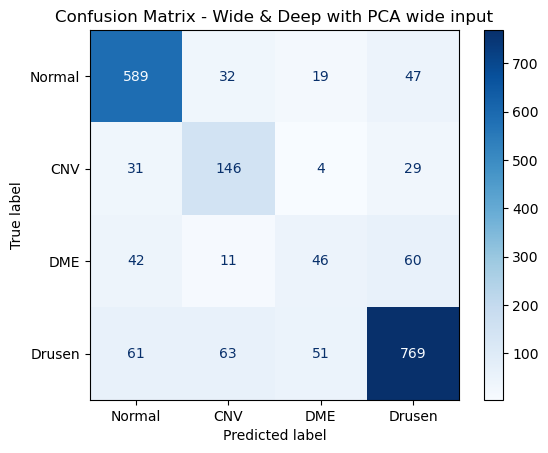

Test AUC Macro:    0.8885
Test AUC Weighted: 0.9186


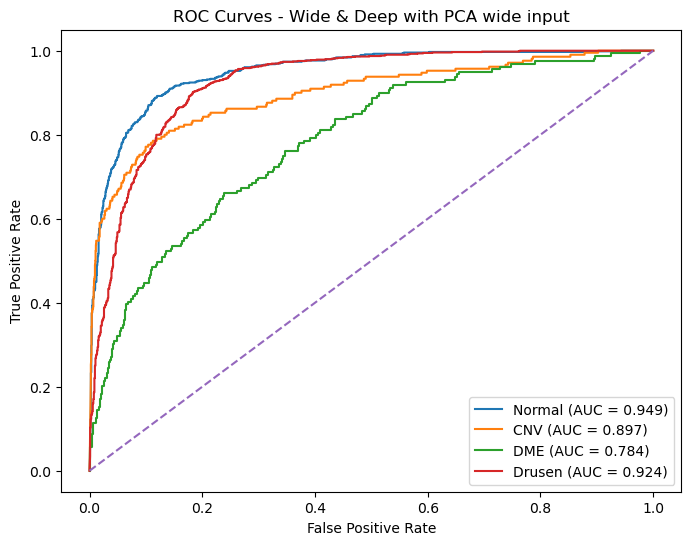

In [37]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
)
from scikeras.wrappers import KerasClassifier

from utils import flattener

x_tr, y_tr = stratified_subset(train_images, train_labels, 30000)
x_va, y_va = stratified_subset(val_images, val_labels, 2000)


def create_wide_and_deep_pca(meta, n_pca=50):
    n_features = meta["X_shape_"][1]

    inputs = tf.keras.layers.Input(shape=(n_features,))
    wide_input = tf.keras.layers.Lambda(lambda x: x[:, :n_pca])(inputs)
    deep_input = tf.keras.layers.Lambda(lambda x: x[:, n_pca:])(inputs)

    deep = tf.keras.layers.Dense(300, activation="relu")(deep_input)
    deep = tf.keras.layers.Dense(300, activation="relu")(deep)

    concat = tf.keras.layers.Concatenate()([wide_input, deep])
    output = tf.keras.layers.Dense(4, activation="softmax")(concat)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )
    return model


def build_wide_deep_pipeline():
    """Returns a fresh pipeline so each CV fold starts from scratch."""
    N_PCA = 50

    wide_deep_features = FeatureUnion([
        ("pca",         PCA(n_components=N_PCA, random_state=42)),
        ("passthrough", FunctionTransformer(lambda x: x, validate=False)),
    ])

    clf_wide_pca = KerasClassifier(
        model=create_wide_and_deep_pca,
        model__n_pca=N_PCA,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping_cb, tensorboard_cb],
        verbose=0,
    )

    return Pipeline([
        ("flat",     flattener),
        ("scale",    MinMaxScaler()),
        ("features", wide_deep_features),
        ("model",    clf_wide_pca),
    ])


# ============================================================
# Wide & Deep evaluation (no sample weights)
# ============================================================
name = "Wide & Deep with PCA wide input"

y_tr_flat = np.ravel(y_tr)
y_te_flat = np.ravel(y_va)

# ------- Cross-validation -------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc, cv_prec, cv_rec = [], [], []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(x_tr, y_tr_flat), start=1):
    x_fold_tr, x_fold_va = x_tr[train_idx], x_tr[val_idx]
    y_fold_tr, y_fold_va = y_tr_flat[train_idx], y_tr_flat[val_idx]

    fold_pipe = build_wide_deep_pipeline()
    fold_pipe.fit(x_fold_tr, y_fold_tr)

    fold_pred = fold_pipe.predict(x_fold_va)
    if fold_pred.ndim > 1:
        fold_pred = fold_pred.argmax(axis=1)

    cv_acc.append(accuracy_score(y_fold_va, fold_pred))
    cv_prec.append(precision_score(y_fold_va, fold_pred, average="weighted", zero_division=1))
    cv_rec.append(recall_score(y_fold_va, fold_pred, average="weighted", zero_division=1))
    print(f"  fold {fold_idx}: acc={cv_acc[-1]:.4f}  prec={cv_prec[-1]:.4f}  rec={cv_rec[-1]:.4f}")

    tf.keras.backend.clear_session()

cv_acc, cv_prec, cv_rec = map(np.array, (cv_acc, cv_prec, cv_rec))
print("\nCross-Validation Results:")
print(f"Accuracy:  {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"Precision: {cv_prec.mean():.4f}")
print(f"Recall:    {cv_rec.mean():.4f}")

# ------- Final fit on full training set -------
final_pipe = build_wide_deep_pipeline()
t1 = time.time()
final_pipe.fit(x_tr, y_tr_flat)
t2 = time.time()

# ------- Test set evaluation -------
y_score = final_pipe.predict_proba(x_va)
y_pred = y_score.argmax(axis=1)

acc = accuracy_score(y_te_flat, y_pred)
prec = precision_score(y_te_flat, y_pred, average="weighted", zero_division=1)
rec = recall_score(y_te_flat, y_pred, average="weighted", zero_division=1)

print(f"\nModel: {name}")
print(f"Training Time: {t2 - t1:.3f}s")
print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")

result = {
    "Model": name,
    "CV Accuracy": cv_acc.mean(),
    "CV Precision": cv_prec.mean(),
    "CV Recall": cv_rec.mean(),
    "Train Time (s)": t2 - t1,
    "Test Accuracy": acc,
    "Test Precision": prec,
    "Test Recall": rec,
}

# Confusion matrix
cm = confusion_matrix(y_te_flat, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {name}")
plt.show()

# ROC curves
classes = np.unique(y_te_flat)
y_te_bin = label_binarize(y_te_flat, classes=classes)

auc_macro = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="macro")
auc_weighted = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="weighted")
result["Test AUC Macro"] = auc_macro
result["Test AUC Weighted"] = auc_weighted

print(f"Test AUC Macro:    {auc_macro:.4f}")
print(f"Test AUC Weighted: {auc_weighted:.4f}")

plt.figure(figsize=(8, 6))
for i in range(y_te_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_score[:, i])
    roc_auc_val = auc(fpr, tpr)
    label = class_names[i] if class_names is not None else f"Class {i}"
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves - {name}")
plt.legend()
plt.show()

results_test.append(result)